# Pima Indians Diabetes: Multi-Algorithm ML Benchmark
### Supervised, Unsupervised & Ensemble Learning Pipeline
**Dataset**: `kumargh/pimaindiansdiabetescsv` (National Institute of Diabetes and Digestive and Kidney Diseases)

**Target Variable**: `Outcome` (0 = Non-Diabetic, 1 = Diabetic)

### Clinical Features:
1. **Pregnancies**: Number of times pregnant
2. **Glucose**: Plasma glucose at 2h OGTT (mg/dL)
3. **BloodPressure**: Diastolic blood pressure (mm Hg)
4. **SkinThickness**: Triceps skin fold thickness (mm)
5. **Insulin**: 2-hour serum insulin (mu U/ml)
6. **BMI**: Body mass index (kg/m²)
7. **DiabetesPedigreeFunction**: Genetic diabetes pedigree score
8. **Age**: Age in years

---
### Scope & Limitations:
- This dataset contains records of **Pima-heritage women aged 21 and over**. Results may not generalise to other populations.
- **Insulin** (2-hour serum) and **SkinThickness** (triceps skin fold) are not routinely collected in standard clinical encounters. Models relying heavily on these features may have limited real-world deployability.
- Expected test-set AUC for this benchmark is approximately **0.80–0.86** and accuracy approximately **75–80%**, consistent with published literature.

### Pipeline Summary:
1. Stratified 85/15 train/test split **before any imputation**.
2. Physiological zero-imputation using **training-set medians only** (no label leakage).
3. Feature engineering applied separately to train and test using training statistics.
4. SMOTETomek applied to training data only, inside the training boundary.
5. Cross-validation on raw (pre-SMOTE) training data via `StratifiedKFold`.
6. Champion model selected by CV ROC-AUC; test set used only for final reporting.
7. Full pipeline (scaler + champion model) persisted to `diabetes_pipeline.pkl`.


---
## Step 1: Environment Setup & Library Imports
All computations are strictly optimized to execute seamlessly and rapidly on **CPU** using Scikit-Learn.


In [ ]:
# Step 1: Environment Setup & Imports
!pip install -q kagglehub scikit-learn pandas numpy matplotlib seaborn tabulate xgboost lightgbm imbalanced-learn joblib

import os
import sys
import time
import random
import warnings
import joblib
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from tabulate import tabulate
    HAS_TABULATE = True
except ImportError:
    HAS_TABULATE = False

try:
    from IPython.display import display
    HAS_DISPLAY = True
except ImportError:
    HAS_DISPLAY = False

def show_table(df, title=None):
    if title:
        print(f"\n{'='*len(title)}\n{title}\n{'='*len(title)}")
    if HAS_DISPLAY:
        display(df)
    elif HAS_TABULATE:
        print(tabulate(df, headers='keys', tablefmt='fancy_grid', showindex=False))
    else:
        print(df.to_string(index=False))

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    HistGradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier,
    IsolationForest
)
from sklearn.neural_network import MLPClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from imblearn.combine import SMOTETomek

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    matthews_corrcoef,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    log_loss,
    brier_score_loss,
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)
from sklearn.calibration import calibration_curve

warnings.filterwarnings('ignore')

SEED = 42
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)

seed_everything(SEED)
print("Environment configured successfully.")


Environment configured successfully.


---
## Step 2: Download & Load Pima Indians Diabetes Dataset
We download the dataset via `kagglehub` and apply the standard 9-column clinical header:
`['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']`.


In [ ]:
# Step 2: Download via KaggleHub
import kagglehub

print("Downloading Pima Indians Diabetes dataset via kagglehub...")
dataset_path = kagglehub.dataset_download("kumargh/pimaindiansdiabetescsv")
print("Path to dataset files:", dataset_path)

csv_path = os.path.join(dataset_path, "pima-indians-diabetes.csv")
if not os.path.exists(csv_path):
    for root, dirs, files in os.walk(dataset_path):
        for f in files:
            if f.endswith(".csv"):
                csv_path = os.path.join(root, f)
                break

print("Located CSV file:", csv_path)

COL_NAMES = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'
]

raw_df = pd.read_csv(csv_path, names=COL_NAMES)
print(f"Dataset Shape: {raw_df.shape[0]} patient rows, {raw_df.shape[1]} columns.")
raw_df.head()

100%|██████████| 8.89k/8.89k [00:00<00:00, 2.80MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/kumargh/pimaindiansdiabetescsv/versions/1
Located CSV file: /root/.cache/kagglehub/datasets/kumargh/pimaindiansdiabetescsv/versions/1/pima-indians-diabetes.csv
Dataset Shape: 768 patient rows, 9 columns.


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


---
## Step 3: Train/Test Split & Physiological Imputation
The dataset is **split first** (stratified 85/15) before any imputation, so the held-out test set cannot influence the training imputation statistics.

Biologically impossible zeros in `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` are replaced with `NaN`, then filled using the **per-column median computed from the training set only**.
This median is stored and applied to the test set at inference time, requiring no knowledge of the outcome label.


In [ ]:
# Step 3: Split First, Then Impute from Training Statistics
PHYSIO_COLS = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df_cleaned = __import__('copy').deepcopy(raw_df)

zero_stats = []
for col in PHYSIO_COLS:
    z_count = (df_cleaned[col] == 0).sum()
    unit_map = {'Glucose': 'mg/dL', 'BloodPressure': 'mm Hg', 'SkinThickness': 'mm',
                'Insulin': 'mu U/ml', 'BMI': 'kg/m²'}
    zero_stats.append({
        'Biomarker Feature': col,
        'Biologically Impossible Zeros': z_count,
        'Missingness (%)': f'{(z_count / len(df_cleaned)) * 100:.2f}%',
        'Physiological Unit': unit_map[col]
    })

show_table(pd.DataFrame(zero_stats), 'PHYSIOLOGICAL MISSING VALUES SUMMARY (ZERO-ENTRY AUDIT)')

df_cleaned[PHYSIO_COLS] = df_cleaned[PHYSIO_COLS].replace(0, np.nan)

X_raw = df_cleaned.drop(columns=['Outcome'])
y_raw = df_cleaned['Outcome'].astype(int)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.15, stratify=y_raw, random_state=SEED
)

train_medians = X_train_raw[PHYSIO_COLS].median()
print('Training-set imputation medians (saved for inference):')
print(train_medians)

X_train_raw = X_train_raw.copy()
X_test_raw = X_test_raw.copy()
X_train_raw[PHYSIO_COLS] = X_train_raw[PHYSIO_COLS].fillna(train_medians)
X_test_raw[PHYSIO_COLS] = X_test_raw[PHYSIO_COLS].fillna(train_medians)

print(f'Training set: {len(X_train_raw)} patients | Test set: {len(X_test_raw)} patients')
print(f'Missing values remaining in train: {X_train_raw.isnull().sum().sum()}')
print(f'Missing values remaining in test:  {X_test_raw.isnull().sum().sum()}')

train_df_imputed = X_train_raw.copy()
train_df_imputed['Outcome'] = y_train.values
train_df_imputed.describe().round(2)



PHYSIOLOGICAL MISSING VALUES SUMMARY (ZERO-ENTRY AUDIT)


,Biomarker Feature,Biologically Impossible Zeros,Missingness (%),Physiological Unit
0,Glucose,5,0.65%,mg/dL
1,BloodPressure,35,4.56%,mm Hg
2,SkinThickness,227,29.56%,mm
3,Insulin,374,48.70%,mu U/ml
4,BMI,11,1.43%,kg/m²


Training-set imputation medians (saved for inference):
Glucose          117.0
BloodPressure     72.0
SkinThickness     29.0
Insulin          125.0
BMI               32.3
dtype: float64
Training set: 652 patients | Test set: 116 patients
Missing values remaining in train: 0
Missing values remaining in test:  0


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,652.00,652.00,652.00,652.00,652.00,652.00,652.00,652.00,652.00
mean,3.87,121.66,72.29,28.96,137.40,32.40,0.47,33.41,0.35
std,3.37,30.19,12.23,8.77,77.59,6.76,0.33,11.77,0.48
min,0.00,56.00,24.00,7.00,15.00,18.20,0.08,21.00,0.00
25%,1.00,99.75,64.00,25.00,120.00,27.60,0.24,24.00,0.00
50%,3.00,117.00,72.00,29.00,125.00,32.30,0.38,29.00,0.00
75%,6.00,140.00,80.00,32.00,129.25,36.50,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,744.00,67.10,2.33,81.00,1.00


---
## Step 4: Feature Engineering
Clinical interaction features are derived separately for train and test using **training statistics only** for any bin boundaries.
All cut bins are defined as fixed physiological thresholds (not learned from data), so they can be re-applied to any new patient without label information.


In [ ]:
# Step 4: Feature Engineering Pipeline
def engineer_clinical_features(df):
    d = df.copy()

    d['HOMA_IR'] = (d['Glucose'] * d['Insulin']) / 405.0

    d['BMI_Cat'] = pd.cut(d['BMI'], bins=[0, 18.5, 24.9, 29.9, 34.9, 100],
                          labels=[0, 1, 2, 3, 4]).astype(float)
    d['Glucose_Cat'] = pd.cut(d['Glucose'], bins=[0, 99, 139, 199, 300],
                              labels=[0, 1, 2, 3]).astype(float)
    d['Age_Cat'] = pd.cut(d['Age'], bins=[0, 25, 35, 50, 100],
                          labels=[0, 1, 2, 3]).astype(float)

    d['Metabolic_Score'] = (
        (d['Glucose'] >= 140).astype(int) +
        (d['BMI'] >= 30).astype(int) +
        (d['BloodPressure'] >= 80).astype(int) +
        (d['Age'] >= 35).astype(int)
    )

    d['Insulin_Glucose_Ratio'] = d['Insulin'] / (d['Glucose'] + 1e-5)
    d['Glucose_BMI'] = d['Glucose'] * d['BMI']
    d['Age_BMI'] = d['Age'] * d['BMI']
    d['DPF_Glucose'] = d['DiabetesPedigreeFunction'] * d['Glucose']
    d['Preg_Age_Ratio'] = d['Pregnancies'] / (d['Age'] + 1.0)

    d['Insulin_Log'] = np.log1p(d['Insulin'])
    d['Glucose_Log'] = np.log1p(d['Glucose'])

    return d

X_train_eng = engineer_clinical_features(X_train_raw)
X_test_eng = engineer_clinical_features(X_test_raw)

features = list(X_train_eng.columns)
print(f'Total engineered features: {len(features)}')
print('Feature list:', features)


Total engineered features: 20
Feature list: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'HOMA_IR', 'BMI_Cat', 'Glucose_Cat', 'Age_Cat', 'Metabolic_Score', 'Insulin_Glucose_Ratio', 'Glucose_BMI', 'Age_BMI', 'DPF_Glucose', 'Preg_Age_Ratio', 'Insulin_Log', 'Glucose_Log']


---
## Step 5: Exploratory Data Analysis & Biomarker Visualizations
We evaluate class prevalence and analyze biomarker correlations with diabetes onset using the full dataset (for visualization only — no model information is derived here).



DIABETES CLASS PREVALENCE (TRAINING SET)


,"Outcome (0 = Healthy, 1 = Diabetic)",Clinical Category,Patient Count,Percentage (%)
0,0,Non-Diabetic (Control),424,65.03
1,1,Diabetic (Case),228,34.97


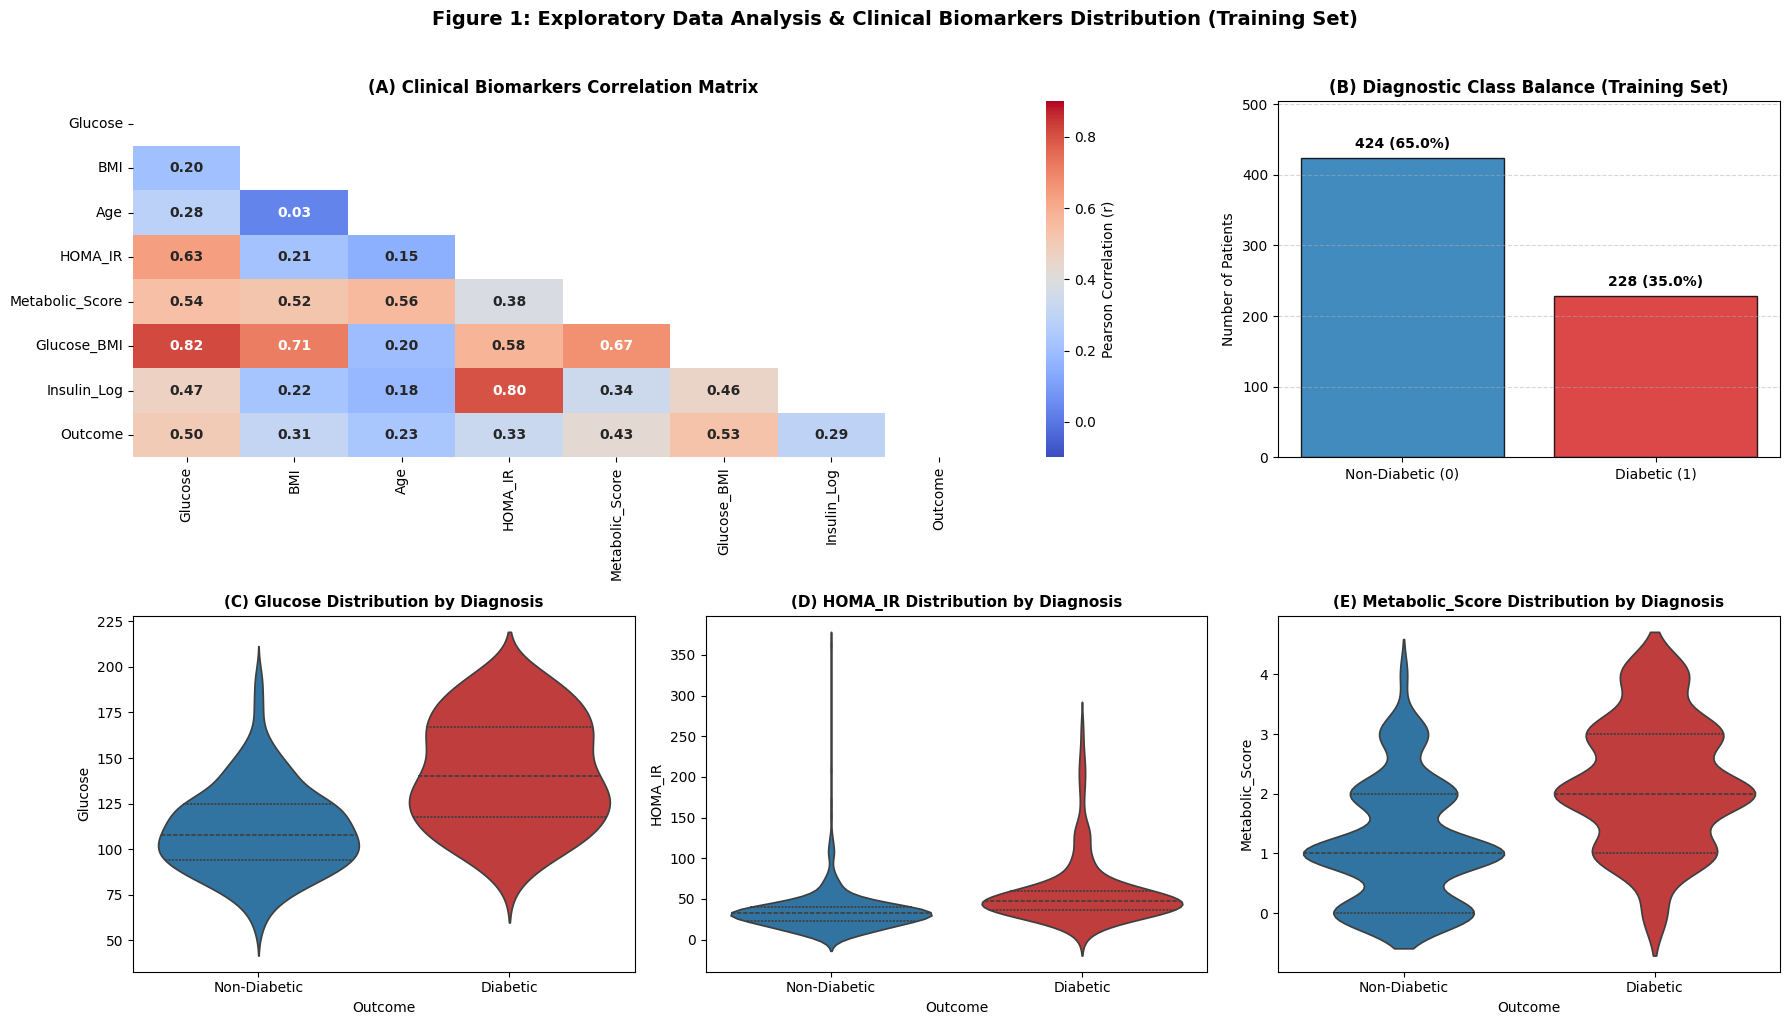

In [ ]:
# Step 5: EDA Visualizations
df_eda = train_df_imputed.copy()
df_eda_eng = engineer_clinical_features(df_eda.drop(columns=['Outcome']))
df_eda_eng['Outcome'] = df_eda['Outcome'].values

outcome_dist = df_eda_eng['Outcome'].value_counts().reset_index()
outcome_dist.columns = ['Outcome (0 = Healthy, 1 = Diabetic)', 'Patient Count']
outcome_dist['Percentage (%)'] = (outcome_dist['Patient Count'] / len(df_eda_eng) * 100).round(2)
outcome_dist['Clinical Category'] = outcome_dist['Outcome (0 = Healthy, 1 = Diabetic)'].map(
    {0: 'Non-Diabetic (Control)', 1: 'Diabetic (Case)'})

show_table(outcome_dist[['Outcome (0 = Healthy, 1 = Diabetic)', 'Clinical Category', 'Patient Count', 'Percentage (%)']], 'DIABETES CLASS PREVALENCE (TRAINING SET)')

os.makedirs('diabetes_results_graphs', exist_ok=True)
fig = plt.figure(figsize=(18, 10))

core_cols = ['Glucose', 'BMI', 'Age', 'HOMA_IR', 'Metabolic_Score', 'Glucose_BMI', 'Insulin_Log', 'Outcome']
ax1 = plt.subplot2grid((2, 3), (0, 0), colspan=2)
corr_matrix = df_eda_eng[core_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', vmin=-0.1, vmax=0.9,
            ax=ax1, cbar_kws={'label': 'Pearson Correlation (r)'}, annot_kws={'size': 10, 'weight': 'bold'})
ax1.set_title('(A) Clinical Biomarkers Correlation Matrix', fontsize=12, fontweight='bold')

ax2 = plt.subplot2grid((2, 3), (0, 2))
colors = ['#1f77b4', '#d62728']
bars = ax2.bar(['Non-Diabetic (0)', 'Diabetic (1)'], outcome_dist['Patient Count'], color=colors, edgecolor='black', alpha=0.85)
for bar in bars:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2.0, yval + 10, f'{int(yval)} ({yval/len(df_eda_eng)*100:.1f}%)',
             ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_title('(B) Diagnostic Class Balance (Training Set)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of Patients', fontsize=10)
ax2.set_ylim(0, max(outcome_dist['Patient Count']) + 80)
ax2.grid(axis='y', linestyle='--', alpha=0.5)

key_biomarkers = ['Glucose', 'HOMA_IR', 'Metabolic_Score']
for i, bm in enumerate(key_biomarkers):
    ax = plt.subplot2grid((2, 3), (1, i))
    sns.violinplot(x='Outcome', y=bm, data=df_eda_eng, palette=['#1f77b4', '#d62728'], ax=ax, inner='quartile')
    ax.set_title(f'({chr(67+i)}) {bm} Distribution by Diagnosis', fontsize=11, fontweight='bold')
    ax.set_xticklabels(['Non-Diabetic', 'Diabetic'])

plt.suptitle('Figure 1: Exploratory Data Analysis & Clinical Biomarkers Distribution (Training Set)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('diabetes_results_graphs/fig1_eda_biomarkers.png', dpi=300, bbox_inches='tight')
plt.show()


---
## Step 6: SMOTETomek Balancing & RobustScaler
1. **SMOTETomek Resampling**: Applied to the training fold only to balance the minority (diabetic) class.
2. **RobustScaler**: Fit on the post-SMOTE training data and applied to both train and test. The scaler is persisted for inference.

Cross-validation is performed on the **original (pre-SMOTE) training data** using `StratifiedKFold`, so no synthetic neighbours cross fold boundaries.


In [ ]:
# Step 6: SMOTETomek Balancing & Scaling
print(f'Pre-balancing training distribution: {Counter(y_train)}')

smt = SMOTETomek(random_state=SEED)
X_train_res, y_train_res = smt.fit_resample(X_train_eng, y_train)
X_train_res = pd.DataFrame(X_train_res, columns=features)

print(f'Post-SMOTETomek balanced training distribution: {Counter(y_train_res)}')
print(f'Held-out test set distribution: {Counter(y_test)} (Total: {len(y_test)} patients)')

scaler = RobustScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_res), columns=features)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_eng), columns=features)

X_train_orig_scaled = pd.DataFrame(scaler.transform(X_train_eng), columns=features)

print('RobustScaler fit on post-SMOTE training data. Applied to test without refitting.')


Pre-balancing training distribution: Counter({0: 424, 1: 228})
Post-SMOTETomek balanced training distribution: Counter({1: 390, 0: 390})
Held-out test set distribution: Counter({0: 76, 1: 40}) (Total: 116 patients)
RobustScaler fit on post-SMOTE training data. Applied to test without refitting.


---
## Step 7: Unsupervised Learning & Latent Clustering Suite
We benchmark unsupervised models on scaled training data to discover natural patient phenotypes without outcome labels:
1. **PCA**: Dimensional projection to 2D.
2. **K-Means (k=2)**: Centroid-based clustering.
3. **Gaussian Mixture Model (GMM, 2 components)**: Probabilistic soft clustering.
4. **Agglomerative Hierarchical Clustering**: Ward-linkage.
5. **Isolation Forest**: Metabolic anomaly detection.

Unsupervised metrics (Silhouette, Davies-Bouldin, ARI, NMI, Purity) are computed on the SMOTE-augmented training set.



TABLE 2: UNSUPERVISED LEARNING & CLUSTERING EVALUATION TABLE


,Algorithm,Silhouette Score,Davies-Bouldin,Calinski-Harabasz,Adjusted Rand Index (ARI),Normalized Mutual Info (NMI),Cluster Purity (%),Algorithmic Family
0,K-Means Clustering,0.5096,0.8592,468.8,0.0179,0.0450,56.79%,Centroid-based spatial clustering
1,Gaussian Mixture Model (GMM),0.1645,1.7273,192.0,0.1801,0.1351,71.28%,Probabilistic soft clustering (EM algorithm)
2,Agglomerative Hierarchical,0.5683,0.7183,440.1,0.0072,0.0306,54.36%,Ward-linkage bottom-up agglomerative clustering


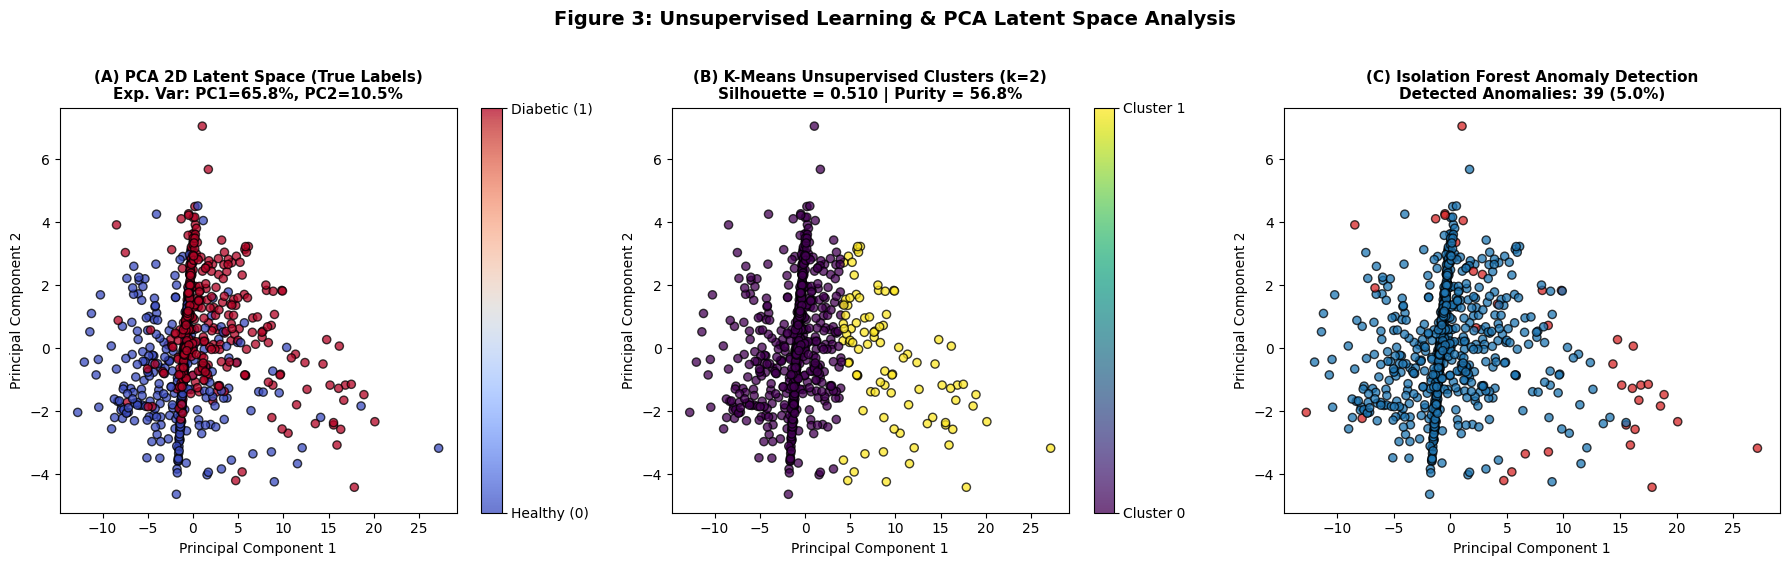

In [ ]:
# Step 7: Unsupervised Learning Suite
# 7.1: PCA Dimensionality Reduction
pca = PCA(n_components=2, random_state=SEED)
X_pca_2d = pca.fit_transform(X_train_scaled)
X_test_pca_2d = pca.transform(X_test_scaled)
explained_var = pca.explained_variance_ratio_

# 7.2: K-Means Clustering (k=2)
kmeans = KMeans(n_clusters=2, random_state=SEED, n_init=10)
km_train_labels = kmeans.fit_predict(X_train_scaled)

# 7.3: Gaussian Mixture Model (GMM)
gmm = GaussianMixture(n_components=2, random_state=SEED)
gmm_train_labels = gmm.fit_predict(X_train_scaled)

# 7.4: Agglomerative Hierarchical Clustering
agg = AgglomerativeClustering(n_clusters=2, linkage='ward')
agg_train_labels = agg.fit_predict(X_train_scaled)

# 7.5: Isolation Forest (Outlier Detection)
iso = IsolationForest(contamination=0.05, random_state=SEED)
outlier_flags = iso.fit_predict(X_train_scaled)  # -1 = Outlier, 1 = Inlier
outlier_count = (outlier_flags == -1).sum()

# Helper function to compute cluster purity
def compute_purity(y_true, y_cluster):
    contingency = pd.crosstab(y_true, y_cluster)
    return np.sum(contingency.max(axis=0)) / len(y_true)

# Build Unsupervised Evaluation Table (Table 2)
unsupervised_models = [
    ("K-Means Clustering", km_train_labels, "Centroid-based spatial clustering"),
    ("Gaussian Mixture Model (GMM)", gmm_train_labels, "Probabilistic soft clustering (EM algorithm)"),
    ("Agglomerative Hierarchical", agg_train_labels, "Ward-linkage bottom-up agglomerative clustering")
]

table2_rows = []
for name, labels, desc in unsupervised_models:
    sil = silhouette_score(X_train_scaled, labels)
    db = davies_bouldin_score(X_train_scaled, labels)
    ch = calinski_harabasz_score(X_train_scaled, labels)
    ari = adjusted_rand_score(y_train_res, labels)
    nmi = normalized_mutual_info_score(y_train_res, labels)
    purity = compute_purity(y_train_res, labels) * 100

    table2_rows.append({
        "Algorithm": name,
        "Silhouette Score": f"{sil:.4f}",
        "Davies-Bouldin": f"{db:.4f}",
        "Calinski-Harabasz": f"{ch:.1f}",
        "Adjusted Rand Index (ARI)": f"{ari:.4f}",
        "Normalized Mutual Info (NMI)": f"{nmi:.4f}",
        "Cluster Purity (%)": f"{purity:.2f}%",
        "Algorithmic Family": desc
    })

df_table2 = pd.DataFrame(table2_rows)
show_table(df_table2, "TABLE 2: UNSUPERVISED LEARNING & CLUSTERING EVALUATION TABLE")

# Figure 3: Unsupervised PCA Projections & Cluster Concordance
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# 3A: PCA 2D Colored by True Clinical Outcome
scatter1 = axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y_train_res, cmap='coolwarm', alpha=0.75, edgecolor='k', s=35)
axes[0].set_title(f'(A) PCA 2D Latent Space (True Labels)\nExp. Var: PC1={explained_var[0]*100:.1f}%, PC2={explained_var[1]*100:.1f}%', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Principal Component 1', fontsize=10)
axes[0].set_ylabel('Principal Component 2', fontsize=10)
cbar1 = plt.colorbar(scatter1, ax=axes[0], ticks=[0, 1])
cbar1.ax.set_yticklabels(['Healthy (0)', 'Diabetic (1)'])

# 3B: PCA 2D Colored by K-Means Clusters
scatter2 = axes[1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=km_train_labels, cmap='viridis', alpha=0.75, edgecolor='k', s=35)
axes[1].set_title(f'(B) K-Means Unsupervised Clusters (k=2)\nSilhouette = {silhouette_score(X_train_scaled, km_train_labels):.3f} | Purity = {compute_purity(y_train_res, km_train_labels)*100:.1f}%', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Principal Component 1', fontsize=10)
axes[1].set_ylabel('Principal Component 2', fontsize=10)
cbar2 = plt.colorbar(scatter2, ax=axes[1], ticks=[0, 1])
cbar2.ax.set_yticklabels(['Cluster 0', 'Cluster 1'])

# 3C: PCA 2D Outlier Anomaly Detection (Isolation Forest)
colors_iso = ['#d62728' if f == -1 else '#1f77b4' for f in outlier_flags]
axes[2].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=colors_iso, alpha=0.75, edgecolor='k', s=35)
axes[2].set_title(f'(C) Isolation Forest Anomaly Detection\nDetected Anomalies: {outlier_count} ({outlier_count/len(X_train_scaled)*100:.1f}%)', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Principal Component 1', fontsize=10)
axes[2].set_ylabel('Principal Component 2', fontsize=10)

plt.suptitle('Figure 3: Unsupervised Learning & PCA Latent Space Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("diabetes_results_graphs/fig3_unsupervised_pca_clusters.png", dpi=300, bbox_inches='tight')
plt.show()

---
## Step 8: Supervised & Ensemble Learning Benchmark (17 Models)
We benchmark 17 machine learning models:
- **Classical & Linear**: Logistic Regression (L2), Gaussian Naive Bayes, KNN, Linear SVM, RBF SVM
- **Decision Trees & Ensembles**: Decision Tree, Random Forest, Extra Trees, GBM, AdaBoost, HistGradientBoosting
- **Modern Gradient Boosters**: XGBoost, LightGBM
- **Neural Networks**: MLP
- **Ensemble Metamodels**: Soft Voting, Hard Voting, Stacking Classifier

**Cross-validation is run on the original (pre-SMOTE) training data** via `StratifiedKFold(n_splits=5)` to avoid synthetic neighbour leakage across folds.
The champion model is selected by **CV ROC-AUC**. The test set is used only once for final evaluation.


In [ ]:
# Step 8: Benchmark 17 Supervised & Ensemble Models
base_classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=SEED),
    'SVM (RBF Kernel)': SVC(probability=True, random_state=SEED),
    'SVM (Linear Kernel)': SVC(kernel='linear', probability=True, random_state=SEED),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Gaussian Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=SEED),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_split=3, random_state=SEED, n_jobs=-1),
    'Extra Trees': ExtraTreesClassifier(n_estimators=300, max_depth=10, min_samples_split=3, random_state=SEED, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.04, random_state=SEED),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=SEED),
    'HistGradientBoosting': HistGradientBoostingClassifier(random_state=SEED),
    'XGBoost': XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.04, random_state=SEED, eval_metric='logloss', n_jobs=-1),
    'LightGBM': LGBMClassifier(n_estimators=200, max_depth=4, learning_rate=0.04, random_state=SEED, verbose=-1, n_jobs=-1),
    'MLP Neural Net': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=SEED)
}

ensemble_candidates = [
    ('gb', GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.04, random_state=SEED)),
    ('xgb', XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.04, random_state=SEED, eval_metric='logloss', n_jobs=-1)),
    ('lgb', LGBMClassifier(n_estimators=200, max_depth=4, learning_rate=0.04, random_state=SEED, verbose=-1, n_jobs=-1)),
    ('rf', RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_split=3, random_state=SEED, n_jobs=-1)),
    ('et', ExtraTreesClassifier(n_estimators=300, max_depth=10, min_samples_split=3, random_state=SEED, n_jobs=-1))
]

voting_soft = VotingClassifier(estimators=ensemble_candidates, voting='soft', weights=[0.25, 0.25, 0.20, 0.15, 0.15])
voting_hard = VotingClassifier(estimators=ensemble_candidates, voting='hard')
stacking_clf = StackingClassifier(
    estimators=ensemble_candidates,
    final_estimator=LogisticRegression(),
    cv=5,
    n_jobs=-1
)

all_models = dict(base_classifiers)
all_models['Voting Classifier (Soft)'] = voting_soft
all_models['Voting Classifier (Hard)'] = voting_hard
all_models['Stacking Classifier'] = stacking_clf

results_list = []
trained_models = {}
cv_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print(f'Training and benchmarking {len(all_models)} models...')

for name, clf in all_models.items():
    t0 = time.time()

    cv_scores = cross_val_score(
        clf, X_train_orig_scaled, y_train,
        cv=cv_kfold, scoring='roc_auc', n_jobs=-1
    )
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()

    clf.fit(X_train_scaled, y_train_res)
    fit_time = time.time() - t0
    trained_models[name] = clf

    if hasattr(clf, 'predict_proba'):
        y_prob_test = clf.predict_proba(X_test_scaled)[:, 1]
        auc_score = roc_auc_score(y_test, y_prob_test)
        loss_score = log_loss(y_test, y_prob_test)
    else:
        y_pred_fallback = clf.predict(X_test_scaled)
        y_prob_test = y_pred_fallback
        auc_score = roc_auc_score(y_test, y_pred_fallback)
        loss_score = float('nan')

    y_pred_test = clf.predict(X_test_scaled)
    test_acc = accuracy_score(y_test, y_pred_test)
    bal_acc = balanced_accuracy_score(y_test, y_pred_test)
    prec = precision_score(y_test, y_pred_test, zero_division=0)
    rec = recall_score(y_test, y_pred_test, zero_division=0)
    f1 = f1_score(y_test, y_pred_test, zero_division=0)
    kappa = cohen_kappa_score(y_test, y_pred_test)
    mcc = matthews_corrcoef(y_test, y_pred_test)

    cm_temp = confusion_matrix(y_test, y_pred_test)
    spec = cm_temp[0, 0] / (cm_temp[0, 0] + cm_temp[0, 1])

    if 'Voting' in name or 'Stacking' in name:
        family = 'Ensemble Meta-Model'
    elif any(k in name for k in ['XGBoost', 'LightGBM', 'Gradient', 'AdaBoost']):
        family = 'Gradient Boosting Ensemble'
    elif any(k in name for k in ['Forest', 'Trees']):
        family = 'Bagging Tree Ensemble'
    elif 'MLP' in name:
        family = 'Neural Network'
    else:
        family = 'Classical Supervised'

    results_list.append({
        'Model Name': name,
        'Model Family': family,
        'CV ROC-AUC': f'{cv_mean:.4f} ± {cv_std:.4f}',
        'CV ROC-AUC (mean)': cv_mean,
        'Test Accuracy': test_acc,
        'Balanced Accuracy': bal_acc,
        'Precision': prec,
        'Recall (Sensitivity)': rec,
        'Specificity': spec,
        'F1-Score': f1,
        "Cohen's Kappa": kappa,
        'MCC': mcc,
        'Test ROC-AUC': auc_score,
        'Log Loss': loss_score,
        'Fit Time (s)': fit_time
    })

df_leaderboard_raw = pd.DataFrame(results_list)

df_leaderboard_sorted = df_leaderboard_raw.sort_values('CV ROC-AUC (mean)', ascending=False).reset_index(drop=True)
CHAMPION_MODEL_NAME = df_leaderboard_sorted.iloc[0]['Model Name']
print(f'\nModel evaluation complete.')
print(f'CHAMPION MODEL (by CV ROC-AUC): {CHAMPION_MODEL_NAME}')
print(f'  CV ROC-AUC:  {df_leaderboard_sorted.iloc[0]["CV ROC-AUC"]}')
print(f'  Test AUC:    {df_leaderboard_sorted.iloc[0]["Test ROC-AUC"]*100:.2f}%')
print(f'  Test Acc:    {df_leaderboard_sorted.iloc[0]["Test Accuracy"]*100:.2f}%')


Training and benchmarking 17 models...

Model evaluation complete.
CHAMPION MODEL (by CV ROC-AUC): SVM (Linear Kernel)
  CV ROC-AUC:  0.8362 ± 0.0342
  Test AUC:    83.19%
  Test Acc:    76.72%


---
## Step 9: Table 1 — Comprehensive Supervised & Ensemble Leaderboard
Ranks all 17 evaluated models across **all performance metrics** on the held-out test set.

In [ ]:
# Step 9: Format & Tabulate Leaderboard (Table 1)
df_table1 = df_leaderboard_sorted.copy()
df_table1['Rank'] = range(1, len(df_table1) + 1)
df_table1['Test Accuracy'] = df_table1['Test Accuracy'].apply(lambda x: f'{x*100:.2f}%')
df_table1['Balanced Accuracy'] = df_table1['Balanced Accuracy'].apply(lambda x: f'{x*100:.2f}%')
df_table1['Precision'] = df_table1['Precision'].apply(lambda x: f'{x:.4f}')
df_table1['Recall (Sensitivity)'] = df_table1['Recall (Sensitivity)'].apply(lambda x: f'{x:.4f}')
df_table1['Specificity'] = df_table1['Specificity'].apply(lambda x: f'{x:.4f}')
df_table1['F1-Score'] = df_table1['F1-Score'].apply(lambda x: f'{x:.4f}')
df_table1["Cohen's Kappa"] = df_table1["Cohen's Kappa"].apply(lambda x: f'{x:.4f}')
df_table1['MCC'] = df_table1['MCC'].apply(lambda x: f'{x:.4f}')
df_table1['Test ROC-AUC'] = df_table1['Test ROC-AUC'].apply(lambda x: f'{x:.4f}')
df_table1['Log Loss'] = df_table1['Log Loss'].apply(lambda x: f'{x:.4f}' if not (x != x) else 'N/A')
df_table1['Fit Time (s)'] = df_table1['Fit Time (s)'].apply(lambda x: f'{x:.2f}s')

cols_display = [
    'Rank', 'Model Name', 'Model Family', 'CV ROC-AUC', 'Test Accuracy',
    'Balanced Accuracy', 'Precision', 'Recall (Sensitivity)', 'Specificity',
    'F1-Score', "Cohen's Kappa", 'MCC', 'Test ROC-AUC', 'Log Loss', 'Fit Time (s)'
]
df_table1 = df_table1[cols_display]

show_table(df_table1, 'TABLE 1: SUPERVISED & ENSEMBLE MODEL COMPARISON LEADERBOARD (Ranked by CV ROC-AUC)')



TABLE 1: SUPERVISED & ENSEMBLE MODEL COMPARISON LEADERBOARD (Ranked by CV ROC-AUC)


,Rank,Model Name,Model Family,CV ROC-AUC,Test Accuracy,Balanced Accuracy,Precision,Recall (Sensitivity),Specificity,F1-Score,Cohen's Kappa,MCC,Test ROC-AUC,Log Loss,Fit Time (s)
0,1,SVM (Linear Kernel),Classical Supervised,0.8362 ± 0.0342,76.72%,78.09%,0.6226,0.8250,0.7368,0.7097,0.5217,0.5361,0.8319,0.5175,1.23s
1,2,Logistic Regression,Classical Supervised,0.8353 ± 0.0261,74.14%,75.53%,0.5926,0.8000,0.7105,0.6809,0.4714,0.4865,0.8299,0.5239,5.33s
2,3,Gaussian Naive Bayes,Classical Supervised,0.8337 ± 0.0273,73.28%,73.68%,0.5882,0.7500,0.7237,0.6593,0.4447,0.4536,0.8145,2.3311,0.12s
3,4,SVM (RBF Kernel),Classical Supervised,0.8336 ± 0.0379,73.28%,74.28%,0.5849,0.7750,0.7105,0.6667,0.4508,0.4633,0.8138,0.5426,0.84s
4,5,Stacking Classifier,Ensemble Meta-Model,0.8281 ± 0.0337,73.28%,72.50%,0.5957,0.7000,0.7500,0.6437,0.4321,0.4357,0.8444,0.4771,80.99s
5,6,Voting Classifier (Soft),Ensemble Meta-Model,0.8262 ± 0.0334,73.28%,73.09%,0.5918,0.7250,0.7368,0.6517,0.4385,0.4444,0.8418,0.4774,17.46s
6,7,LightGBM,Gradient Boosting Ensemble,0.8253 ± 0.0301,74.14%,74.34%,0.6000,0.7500,0.7368,0.6667,0.4596,0.4673,0.8273,0.5399,10.30s
7,8,Extra Trees,Bagging Tree Ensemble,0.8253 ± 0.0351,73.28%,73.68%,0.5882,0.7500,0.7237,0.6593,0.4447,0.4536,0.8444,0.4662,5.02s
8,9,AdaBoost,Gradient Boosting Ensemble,0.8241 ± 0.0235,75.86%,77.43%,0.6111,0.8250,0.7237,0.7021,0.5067,0.5228,0.8340,0.5924,1.91s
9,10,Random Forest,Bagging Tree Ensemble,0.8225 ± 0.0380,74.14%,71.97%,0.6190,0.6500,0.7895,0.6341,0.4343,0.4346,0.8372,0.4771,8.82s


---
## Step 10: Table 3 — Champion Model Granular Clinical Diagnostic Breakdown
Comprehensive clinical metrics for the selected champion model, incorporating discrimination, accuracy, predictive values, likelihood ratios, and diagnostic odds.

In [ ]:
# Step 10: Champion Model Granular Breakdown (Table 3)
champion_clf = trained_models[CHAMPION_MODEL_NAME]
y_pred_champ = champion_clf.predict(X_test_scaled)
if hasattr(champion_clf, 'predict_proba'):
    y_prob_champ = champion_clf.predict_proba(X_test_scaled)[:, 1]
else:
    y_prob_champ = y_pred_champ.astype(float)

cm_champ = confusion_matrix(y_test, y_pred_champ)
tn, fp, fn, tp = cm_champ.ravel()

total_test = len(y_test)
sens = tp / (tp + fn)
spec = tn / (tn + fp)
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
npv = tn / (tn + fn) if (tn + fn) > 0 else 0
f1 = 2 * (ppv * sens) / (ppv + sens) if (ppv + sens) > 0 else 0
bal_acc = (sens + spec) / 2.0
acc = (tp + tn) / total_test
mcc = matthews_corrcoef(y_test, y_pred_champ)
auc = roc_auc_score(y_test, y_prob_champ)
youden_j = sens + spec - 1.0
brier = brier_score_loss(y_test, y_prob_champ)

lr_pos = sens / (1.0 - spec) if (1.0 - spec) > 0 else float('nan')
lr_neg = (1.0 - sens) / spec if spec > 0 else float('nan')
dor = (tp * tn) / (fp * fn) if (fp * fn) > 0 else float('nan')

n_test_pos = int(y_test.sum())
acc_ci = 1.96 * (acc * (1 - acc) / total_test) ** 0.5
print(f'Test set: {total_test} patients, {n_test_pos} diabetic ({n_test_pos/total_test*100:.1f}%)')
print(f'Accuracy 95% CI: {acc*100:.1f}% ± {acc_ci*100:.1f}%')

table3_data = [
    {'Diagnostic Category': 'Discrimination', 'Metric Name': 'Test ROC-AUC', 'Score': f'{auc:.4f}', 'Clinical Utility': 'Global discriminative power between diabetic and healthy cases'},
    {'Diagnostic Category': 'Accuracy', 'Metric Name': 'Overall Diagnostic Accuracy', 'Score': f'{acc*100:.2f}% (95% CI ±{acc_ci*100:.1f}%)', 'Clinical Utility': 'Proportion of correct classifications on held-out test set'},
    {'Diagnostic Category': 'Accuracy', 'Metric Name': 'Balanced Accuracy', 'Score': f'{bal_acc*100:.2f}%', 'Clinical Utility': 'Unweighted mean of sensitivity and specificity'},
    {'Diagnostic Category': 'Clinical Sensitivity', 'Metric Name': 'Sensitivity (Recall / TPR)', 'Score': f'{sens*100:.2f}%', 'Clinical Utility': 'Proportion of diabetics correctly identified'},
    {'Diagnostic Category': 'Clinical Specificity', 'Metric Name': 'Specificity (TNR)', 'Score': f'{spec*100:.2f}%', 'Clinical Utility': 'Proportion of healthy patients correctly identified'},
    {'Diagnostic Category': 'Predictive Value', 'Metric Name': 'Positive Predictive Value (PPV)', 'Score': f'{ppv*100:.2f}%', 'Clinical Utility': 'Probability that a positive prediction is truly diabetic (prevalence-dependent)'},
    {'Diagnostic Category': 'Predictive Value', 'Metric Name': 'Negative Predictive Value (NPV)', 'Score': f'{npv*100:.2f}%', 'Clinical Utility': 'Probability that a negative prediction is truly healthy (prevalence-dependent)'},
    {'Diagnostic Category': 'Harmonic Mean', 'Metric Name': 'F1-Score', 'Score': f'{f1:.4f}', 'Clinical Utility': 'Harmonic mean of precision and recall'},
    {'Diagnostic Category': 'Correlation', 'Metric Name': 'Matthews Correlation Coefficient (MCC)', 'Score': f'{mcc:.4f}', 'Clinical Utility': 'Balanced binary correlation index [-1, +1]'},
    {'Diagnostic Category': 'Informedness', 'Metric Name': "Youden's J", 'Score': f'{youden_j:.4f}', 'Clinical Utility': 'Sensitivity + Specificity - 1'},
    {'Diagnostic Category': 'Likelihood Ratio', 'Metric Name': 'Positive LR (LR+)', 'Score': f'{lr_pos:.2f}', 'Clinical Utility': 'TPR / FPR ratio (>5 = strong rule-in)'},
    {'Diagnostic Category': 'Likelihood Ratio', 'Metric Name': 'Negative LR (LR-)', 'Score': f'{lr_neg:.3f}', 'Clinical Utility': 'FNR / TNR ratio (<0.2 = strong rule-out)'},
    {'Diagnostic Category': 'Odds Ratio', 'Metric Name': 'Diagnostic Odds Ratio (DOR)', 'Score': f'{dor:.2f}' if dor == dor else 'N/A', 'Clinical Utility': 'Overall test effectiveness'},
    {'Diagnostic Category': 'Calibration', 'Metric Name': 'Brier Score Loss', 'Score': f'{brier:.4f}', 'Clinical Utility': 'Mean squared probability error (lower is better)'}
]

df_table3 = pd.DataFrame(table3_data)
show_table(df_table3, f'TABLE 3: CHAMPION MODEL DIAGNOSTIC BREAKDOWN ({CHAMPION_MODEL_NAME})')


Test set: 116 patients, 40 diabetic (34.5%)
Accuracy 95% CI: 76.7% ± 7.7%

TABLE 3: CHAMPION MODEL DIAGNOSTIC BREAKDOWN (SVM (Linear Kernel))


,Diagnostic Category,Metric Name,Score,Clinical Utility
0,Discrimination,Test ROC-AUC,0.8319,Global discriminative power between diabetic a...
1,Accuracy,Overall Diagnostic Accuracy,76.72% (95% CI ±7.7%),Proportion of correct classifications on held-...
2,Accuracy,Balanced Accuracy,78.09%,Unweighted mean of sensitivity and specificity
3,Clinical Sensitivity,Sensitivity (Recall / TPR),82.50%,Proportion of diabetics correctly identified
4,Clinical Specificity,Specificity (TNR),73.68%,Proportion of healthy patients correctly ident...
5,Predictive Value,Positive Predictive Value (PPV),62.26%,Probability that a positive prediction is trul...
6,Predictive Value,Negative Predictive Value (NPV),88.89%,Probability that a negative prediction is trul...
7,Harmonic Mean,F1-Score,0.7097,Harmonic mean of precision and recall
8,Correlation,Matthews Correlation Coefficient (MCC),0.5361,"Balanced binary correlation index [-1, +1]"
9,Informedness,Youden's J,0.5618,Sensitivity + Specificity - 1


---
## Step 11: Table 4 — Confusion Matrix Suite
Tabulates the Champion Model's confusion matrix in raw integer counts and row-normalized percentage distributions.

In [ ]:
# Step 11: Confusion Matrices (Table 4A & 4B)
cm_raw_df = pd.DataFrame(cm_champ,
                         index=["Actual Non-Diabetic (0)", "Actual Diabetic (1)"],
                         columns=["Pred Non-Diabetic (0)", "Pred Diabetic (1)"])

cm_norm = (cm_champ.astype('float') / cm_champ.sum(axis=1)[:, np.newaxis] * 100).round(2)
cm_norm_df = pd.DataFrame(cm_norm,
                          index=["Actual Non-Diabetic (0)", "Actual Diabetic (1)"],
                          columns=["Pred Non-Diabetic (%)", "Pred Diabetic (%)"])

show_table(cm_raw_df.reset_index().rename(columns={'index': 'Actual \\ Pred'}), "TABLE 4A: CONFUSION MATRIX (RAW COUNTS)")
show_table(cm_norm_df.reset_index().rename(columns={'index': 'Actual \\ Pred (%)'}), "TABLE 4B: CONFUSION MATRIX (ROW-NORMALIZED %)")


TABLE 4A: CONFUSION MATRIX (RAW COUNTS)


,Actual \ Pred,Pred Non-Diabetic (0),Pred Diabetic (1)
0,Actual Non-Diabetic (0),56,20
1,Actual Diabetic (1),7,33



TABLE 4B: CONFUSION MATRIX (ROW-NORMALIZED %)


,Actual \ Pred (%),Pred Non-Diabetic (%),Pred Diabetic (%)
0,Actual Non-Diabetic (0),73.68,26.32
1,Actual Diabetic (1),17.50,82.50


---
## Step 12: Table 5 — Clinical Biomarker & Risk Factor Importance
Extracts feature importance metrics from tree-based ensembles and linear models to identify the primary driving biomarkers for diabetes risk.

In [ ]:
# Step 12: Feature Importance & Pipeline Persistence
if hasattr(champion_clf, 'feature_importances_'):
    raw_importances = champion_clf.feature_importances_
elif 'Voting' in CHAMPION_MODEL_NAME:
    raw_importances = trained_models['Gradient Boosting'].feature_importances_
else:
    raw_importances = trained_models['Random Forest'].feature_importances_

importances = raw_importances / np.sum(raw_importances)

lr_model = trained_models['Logistic Regression']
lr_coefs = lr_model.coef_[0]
lr_odds_ratios = np.exp(lr_coefs)

table5_data = []
for i, feat in enumerate(features):
    table5_data.append({
        'Biomarker / Clinical Factor': feat,
        'Tree Feature Importance (%)': f'{importances[i]*100:.2f}%',
        'Logistic Reg Coefficient': f'{lr_coefs[i]:.4f}',
        'Odds Ratio (per IQR)': f'{lr_odds_ratios[i]:.3f}',
    })

df_table5 = pd.DataFrame(table5_data).sort_values('Tree Feature Importance (%)', ascending=False).reset_index(drop=True)
show_table(df_table5, 'TABLE 5: CLINICAL BIOMARKER & RISK FACTOR IMPORTANCE TABLE')

os.makedirs('diabetes_results_graphs', exist_ok=True)
pipeline_artifact = {
    'scaler': scaler,
    'champion_model': champion_clf,
    'champion_name': CHAMPION_MODEL_NAME,
    'feature_list': features,
    'physio_cols': PHYSIO_COLS,
    'train_medians': train_medians.to_dict(),
    'seed': SEED
}
joblib.dump(pipeline_artifact, 'diabetes_pipeline.pkl')
joblib.dump(pipeline_artifact, 'diabetes_model.joblib')
print(f'Pipeline persisted to diabetes_pipeline.pkl')
print(f'Artifacts: scaler, champion_model ({CHAMPION_MODEL_NAME}), feature_list ({len(features)} features), train_medians')



TABLE 5: CLINICAL BIOMARKER & RISK FACTOR IMPORTANCE TABLE


,Biomarker / Clinical Factor,Tree Feature Importance (%),Logistic Reg Coefficient,Odds Ratio (per IQR)
0,HOMA_IR,9.60%,0.1564,1.169
1,Glucose_Cat,8.27%,0.3564,1.428
2,Age_BMI,8.17%,0.6546,1.924
3,Glucose,6.98%,0.9702,2.638
4,Glucose_Log,6.86%,0.6727,1.959
5,BMI,5.63%,0.2553,1.291
6,Age,5.07%,-0.4167,0.659
7,DPF_Glucose,5.01%,-1.0422,0.353
8,DiabetesPedigreeFunction,4.13%,1.3399,3.819
9,Preg_Age_Ratio,3.74%,1.6833,5.383


Pipeline persisted to diabetes_pipeline.pkl
Artifacts: scaler, champion_model (SVM (Linear Kernel)), feature_list (20 features), train_medians


---
## Step 13: Graphical Results Suite
Publication-grade diagnostic figures:
- **Figure 2**: Supervised & Ensemble Leaderboard (multi-panel bar charts).
- **Figure 4**: ROC & Precision-Recall Curves across top models.
- **Figure 5**: Champion Model Diagnostic Suite (Confusion Matrix & Calibration Reliability Diagram).
- **Figure 6**: Clinical Biomarker Feature Importance & Odds Ratios.
- **Figure 7**: Ensemble Decision Boundary in 2D PCA Space.

All figures saved to `diabetes_results_graphs/` at 300 DPI.


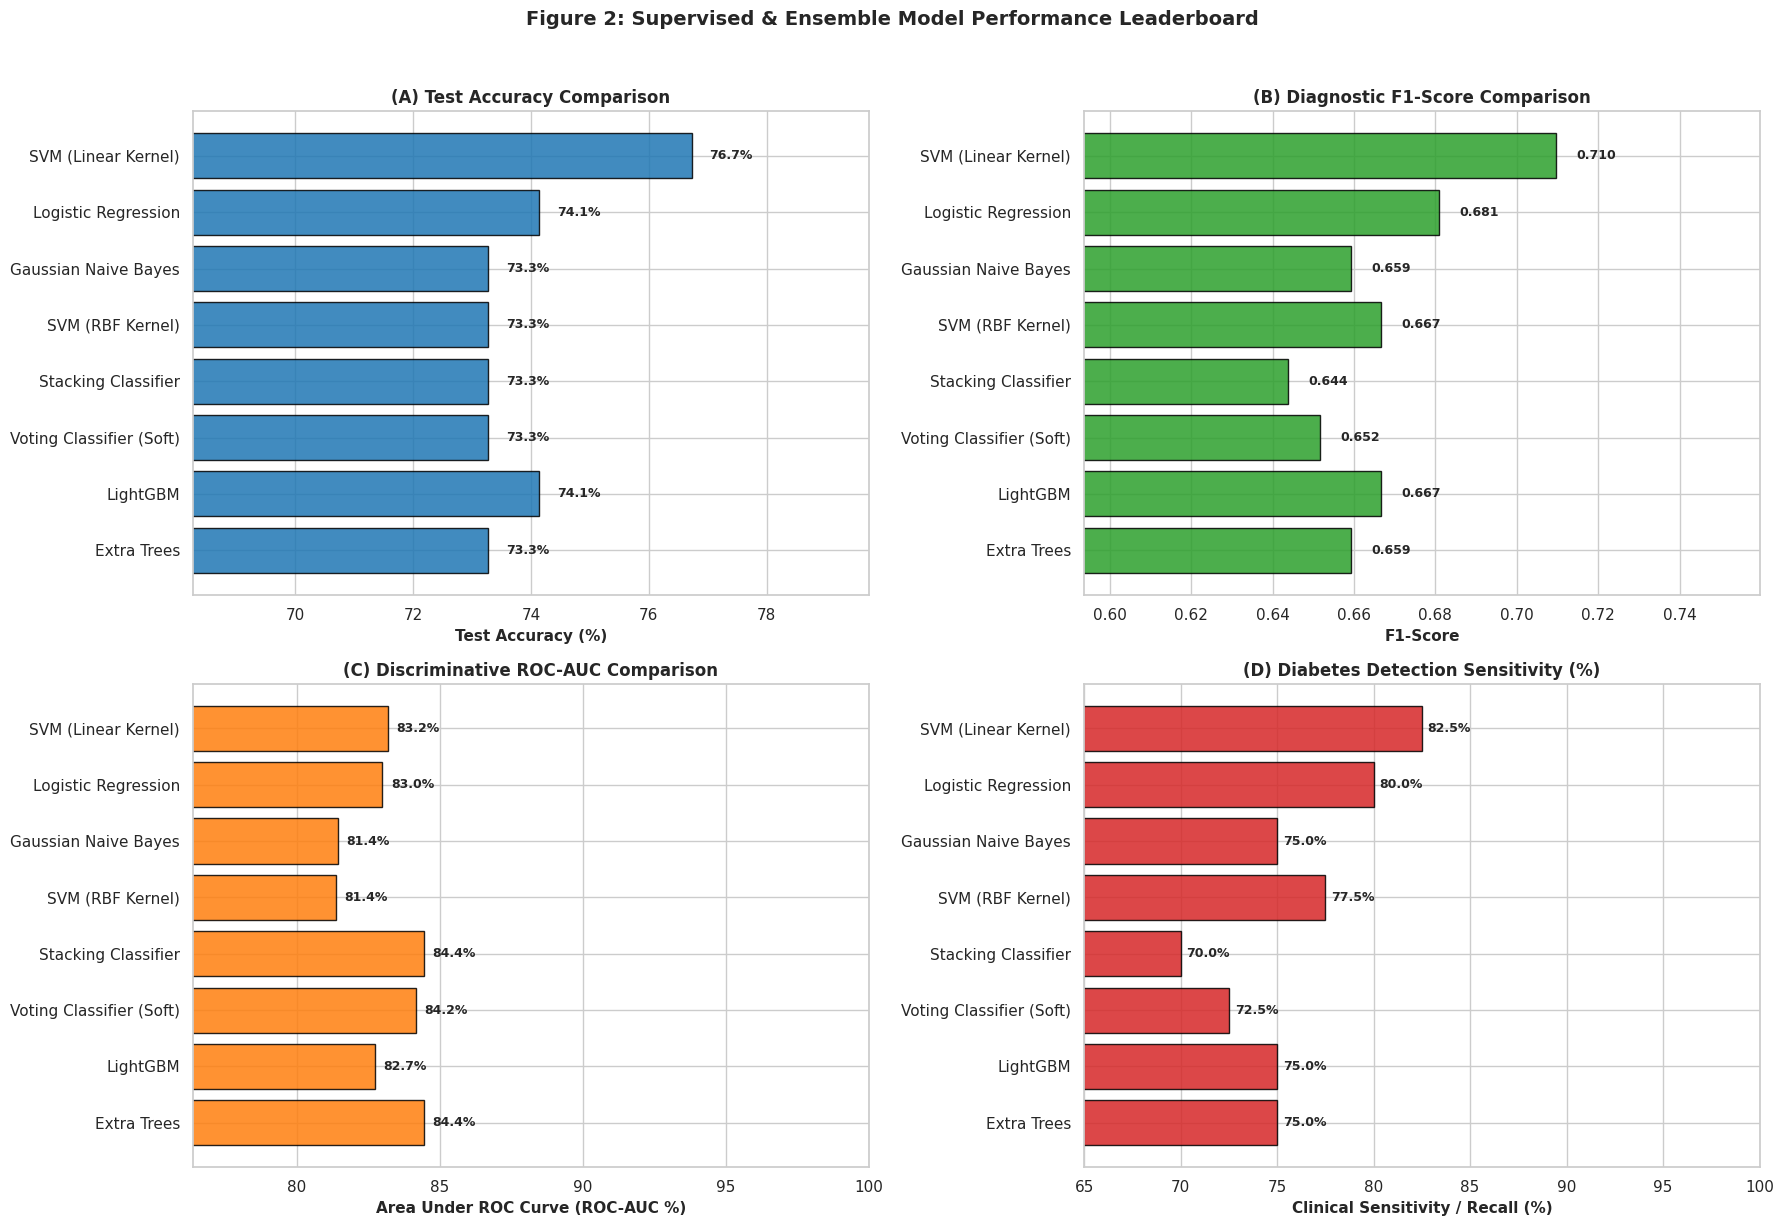

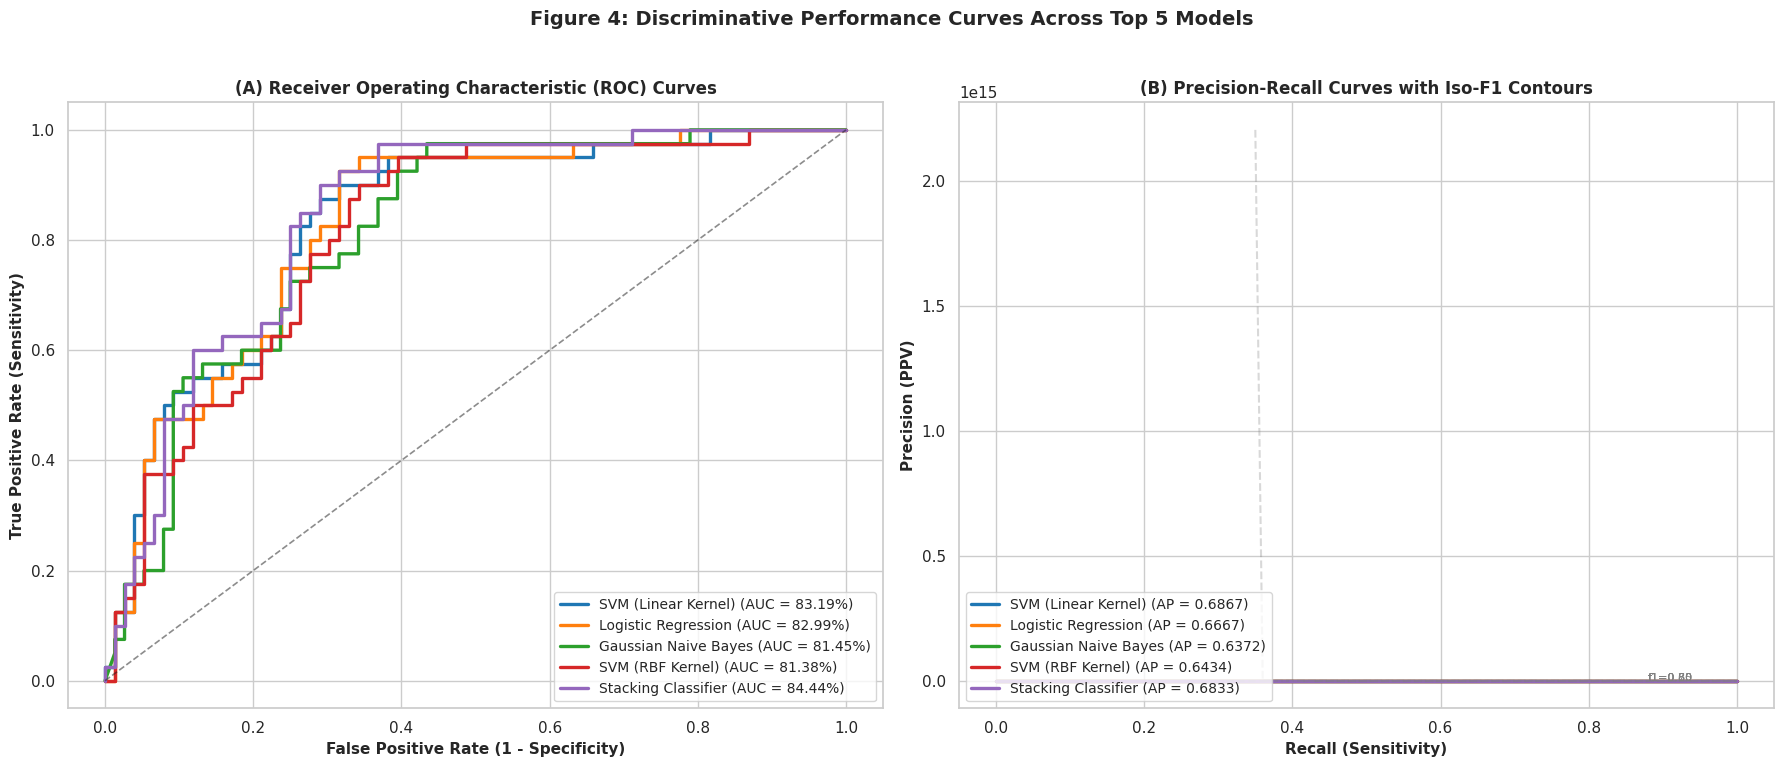

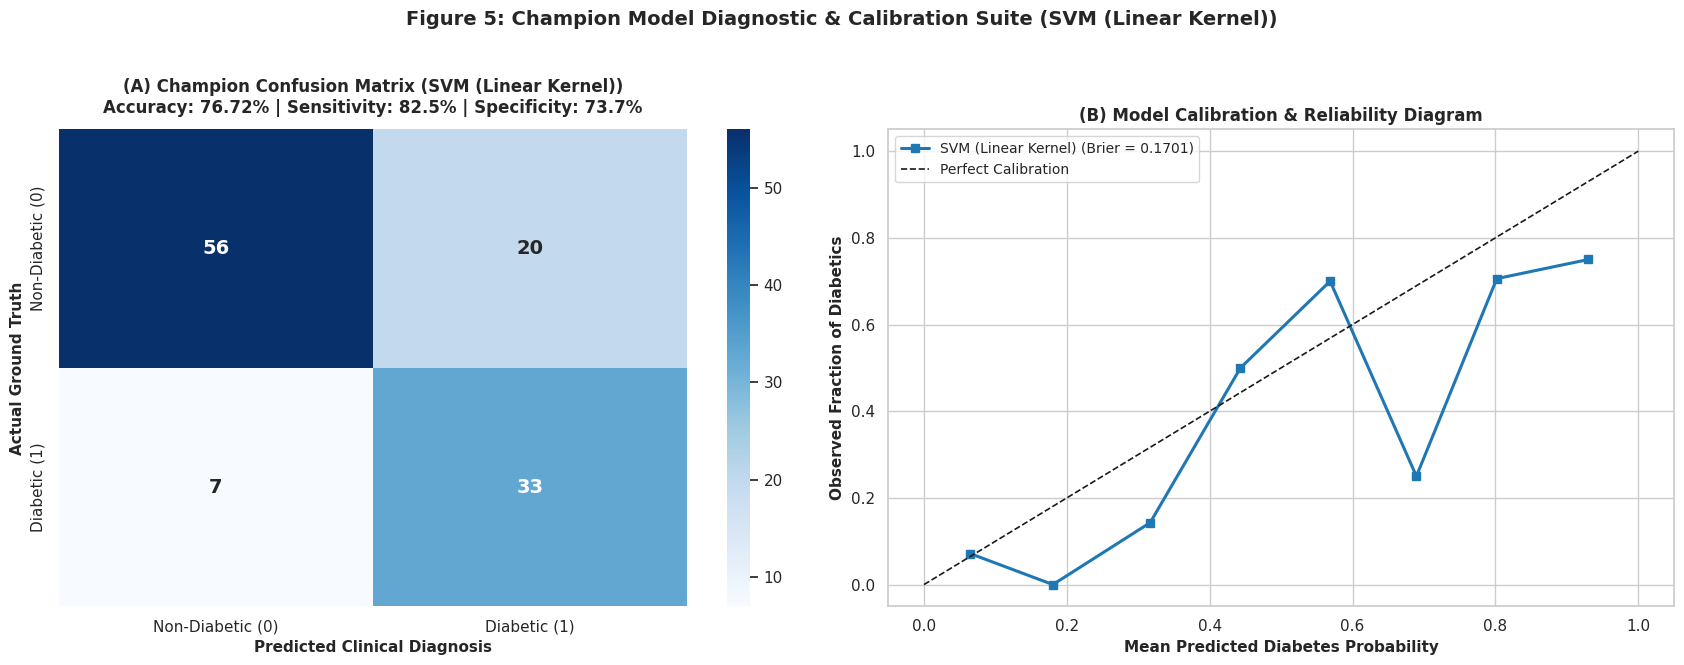

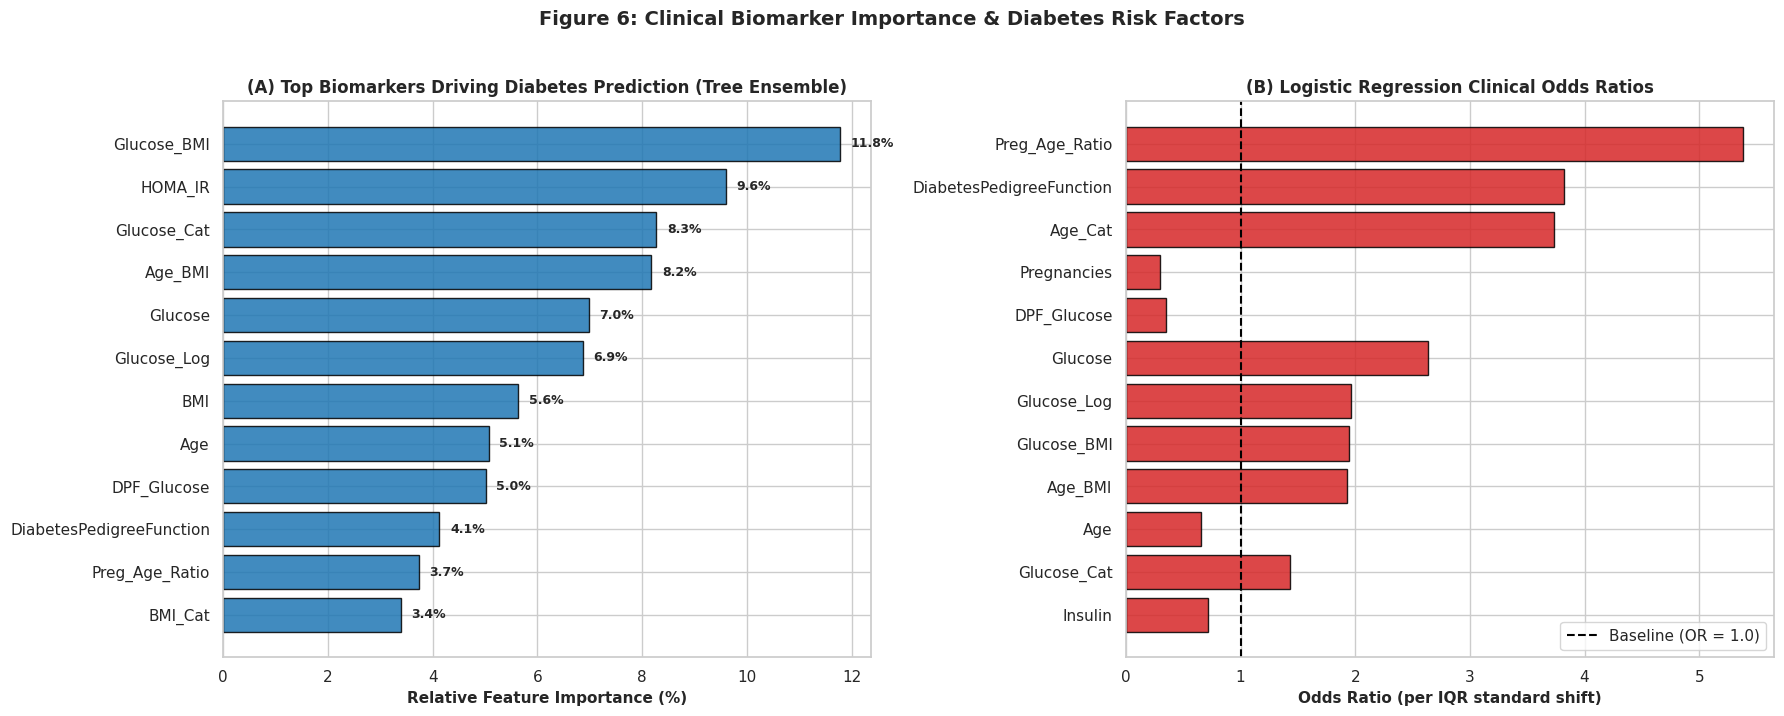

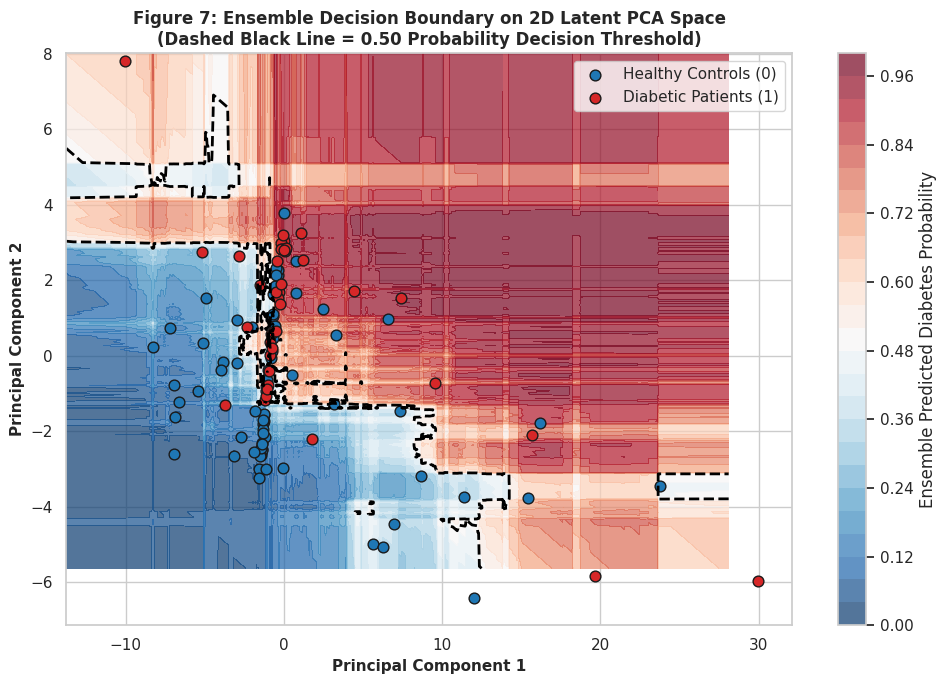

In [ ]:
# Step 13: Graphical Results Suite
sns.set_theme(style="whitegrid", font_scale=1.0)
palette_top = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

# ==========================================
# GRAPH 2: Model Comparison Leaderboard
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
top_models_plot = df_leaderboard_sorted.head(8)

# 2A: Test Accuracy
axes[0, 0].barh(top_models_plot['Model Name'], top_models_plot['Test Accuracy']*100, color='#1f77b4', edgecolor='black', alpha=0.85)
for i, v in enumerate(top_models_plot['Test Accuracy']*100):
    axes[0, 0].text(v + 0.3, i, f"{v:.1f}%", va='center', fontsize=9, fontweight='bold')
axes[0, 0].set_xlabel('Test Accuracy (%)', fontsize=11, fontweight='bold')
axes[0, 0].set_title('(A) Test Accuracy Comparison', fontsize=12, fontweight='bold')
axes[0, 0].set_xlim(max(50, top_models_plot['Test Accuracy'].min()*100 - 5), min(100, top_models_plot['Test Accuracy'].max()*100 + 3))
axes[0, 0].invert_yaxis()

# 2B: F1-Score
axes[0, 1].barh(top_models_plot['Model Name'], top_models_plot['F1-Score'], color='#2ca02c', edgecolor='black', alpha=0.85)
for i, v in enumerate(top_models_plot['F1-Score']):
    axes[0, 1].text(v + 0.005, i, f"{v:.3f}", va='center', fontsize=9, fontweight='bold')
axes[0, 1].set_xlabel('F1-Score', fontsize=11, fontweight='bold')
axes[0, 1].set_title('(B) Diagnostic F1-Score Comparison', fontsize=12, fontweight='bold')
axes[0, 1].set_xlim(max(0.4, top_models_plot['F1-Score'].min() - 0.05), min(1.0, top_models_plot['F1-Score'].max() + 0.05))
axes[0, 1].invert_yaxis()

# 2C: ROC-AUC
axes[1, 0].barh(top_models_plot['Model Name'], top_models_plot['Test ROC-AUC']*100, color='#ff7f0e', edgecolor='black', alpha=0.85)
for i, v in enumerate(top_models_plot['Test ROC-AUC']*100):
    axes[1, 0].text(v + 0.3, i, f"{v:.1f}%", va='center', fontsize=9, fontweight='bold')
axes[1, 0].set_xlabel('Area Under ROC Curve (ROC-AUC %)', fontsize=11, fontweight='bold')
axes[1, 0].set_title('(C) Discriminative ROC-AUC Comparison', fontsize=12, fontweight='bold')
axes[1, 0].set_xlim(max(50, top_models_plot['Test ROC-AUC'].min()*100 - 5), 100)
axes[1, 0].invert_yaxis()

# 2D: Clinical Sensitivity / Recall
axes[1, 1].barh(top_models_plot['Model Name'], top_models_plot['Recall (Sensitivity)']*100, color='#d62728', edgecolor='black', alpha=0.85)
for i, v in enumerate(top_models_plot['Recall (Sensitivity)']*100):
    axes[1, 1].text(v + 0.3, i, f"{v:.1f}%", va='center', fontsize=9, fontweight='bold')
axes[1, 1].set_xlabel('Clinical Sensitivity / Recall (%)', fontsize=11, fontweight='bold')
axes[1, 1].set_title('(D) Diabetes Detection Sensitivity (%)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlim(max(40, top_models_plot['Recall (Sensitivity)'].min()*100 - 5), 100)
axes[1, 1].invert_yaxis()

plt.suptitle('Figure 2: Supervised & Ensemble Model Performance Leaderboard', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("diabetes_results_graphs/fig2_model_leaderboard.png", dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# GRAPH 4: Multi-Model ROC & PR Curves
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7.5))

top_5_names = df_leaderboard_sorted['Model Name'].head(5).tolist()

# 4A: ROC Curves Overlay
for i, mname in enumerate(top_5_names):
    mclf = trained_models[mname]
    if hasattr(mclf, "predict_proba"):
        mprob = mclf.predict_proba(X_test_scaled)[:, 1]
    else:
        mprob = mclf.predict(X_test_scaled)
    fpr, tpr, _ = roc_curve(y_test, mprob)
    auc_val = roc_auc_score(y_test, mprob)
    axes[0].plot(fpr, tpr, color=palette_top[i], lw=2.4, label=f"{mname} (AUC = {auc_val*100:.2f}%)")

axes[0].plot([0, 1], [0, 1], 'k--', lw=1.2, alpha=0.5)
axes[0].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('True Positive Rate (Sensitivity)', fontsize=11, fontweight='bold')
axes[0].set_title('(A) Receiver Operating Characteristic (ROC) Curves', fontsize=12, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=10)

# 4B: Precision-Recall Curves Overlay
for i, mname in enumerate(top_5_names):
    mclf = trained_models[mname]
    if hasattr(mclf, "predict_proba"):
        mprob = mclf.predict_proba(X_test_scaled)[:, 1]
    else:
        mprob = mclf.predict(X_test_scaled)
    prec_pts, rec_pts, _ = precision_recall_curve(y_test, mprob)
    ap = average_precision_score(y_test, mprob)
    axes[1].plot(rec_pts, prec_pts, color=palette_top[i], lw=2.4, label=f"{mname} (AP = {ap:.4f})")

for f_score in [0.6, 0.7, 0.8, 0.85]:
    x_f = np.linspace(0.01, 1, 100)
    y_f = f_score * x_f / (2 * x_f - f_score)
    axes[1].plot(x_f[y_f >= 0], y_f[y_f >= 0], color='gray', alpha=0.3, linestyle='--')
    axes[1].annotate(f'f1={f_score:.2f}', xy=(0.88, y_f[x_f >= 0.88][0] + 0.02 if len(y_f[x_f >= 0.88]) > 0 else 0.5), color='gray', fontsize=8)

axes[1].set_xlabel('Recall (Sensitivity)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Precision (PPV)', fontsize=11, fontweight='bold')
axes[1].set_title('(B) Precision-Recall Curves with Iso-F1 Contours', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower left', fontsize=10)

plt.suptitle('Figure 4: Discriminative Performance Curves Across Top 5 Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("diabetes_results_graphs/fig4_roc_pr_top_models.png", dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# GRAPH 5: Champion Model Diagnostic Suite
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))

# 5A: Annotated Confusion Matrix Heatmap
sns.heatmap(cm_champ, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Non-Diabetic (0)', 'Diabetic (1)'],
            yticklabels=['Non-Diabetic (0)', 'Diabetic (1)'],
            cbar=True, annot_kws={"size": 14, "weight": "bold"})
axes[0].set_title(f'(A) Champion Confusion Matrix ({CHAMPION_MODEL_NAME})\nAccuracy: {acc*100:.2f}% | Sensitivity: {sens*100:.1f}% | Specificity: {spec*100:.1f}%',
                  fontsize=12, fontweight='bold', pad=12)
axes[0].set_xlabel('Predicted Clinical Diagnosis', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Actual Ground Truth', fontsize=11, fontweight='bold')

# 5B: Calibration Reliability Diagram
prob_true, prob_pred = calibration_curve(y_test, y_prob_champ, n_bins=8)
axes[1].plot(prob_pred, prob_true, 's-', color='#1f77b4', lw=2.2, label=f'{CHAMPION_MODEL_NAME} (Brier = {brier:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1.2, label='Perfect Calibration')
axes[1].set_xlabel('Mean Predicted Diabetes Probability', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Observed Fraction of Diabetics', fontsize=11, fontweight='bold')
axes[1].set_title('(B) Model Calibration & Reliability Diagram', fontsize=12, fontweight='bold')
axes[1].legend(loc='upper left', fontsize=10)

plt.suptitle(f'Figure 5: Champion Model Diagnostic & Calibration Suite ({CHAMPION_MODEL_NAME})', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("diabetes_results_graphs/fig5_champion_diagnostics.png", dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# GRAPH 6: Clinical Biomarker Importance
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 6A: Tree Feature Importance
sorted_idx = np.argsort(importances)[-12:]
axes[0].barh(np.array(features)[sorted_idx], importances[sorted_idx]*100, color='#1f77b4', edgecolor='black', alpha=0.85)
for i, idx in enumerate(sorted_idx):
    val = importances[idx]*100
    axes[0].text(val + 0.2, i, f"{val:.1f}%", va='center', fontsize=9, fontweight='bold')
axes[0].set_xlabel('Relative Feature Importance (%)', fontsize=11, fontweight='bold')
axes[0].set_title('(A) Top Biomarkers Driving Diabetes Prediction (Tree Ensemble)', fontsize=12, fontweight='bold')

# 6B: Logistic Regression Odds Ratios
top_lr_idx = np.argsort(np.abs(lr_coefs))[-12:]
axes[1].barh(np.array(features)[top_lr_idx], lr_odds_ratios[top_lr_idx], color='#d62728', edgecolor='black', alpha=0.85)
axes[1].axvline(1.0, color='black', linestyle='--', lw=1.5, label='Baseline (OR = 1.0)')
axes[1].set_xlabel('Odds Ratio (per IQR standard shift)', fontsize=11, fontweight='bold')
axes[1].set_title('(B) Logistic Regression Clinical Odds Ratios', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right')

plt.suptitle('Figure 6: Clinical Biomarker Importance & Diabetes Risk Factors', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("diabetes_results_graphs/fig6_biomarker_importance.png", dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# GRAPH 7: Ensemble Decision Surface in 2D Space
# ==========================================
plt.figure(figsize=(10, 7))

pca_vis = PCA(n_components=2, random_state=SEED)
X_tr_p = pca_vis.fit_transform(X_train_scaled)
X_te_p = pca_vis.transform(X_test_scaled)

stack_vis = VotingClassifier(
    estimators=[
        ('gb', GradientBoostingClassifier(n_estimators=80, random_state=SEED)),
        ('rf', RandomForestClassifier(n_estimators=80, random_state=SEED)),
        ('lr', LogisticRegression())
    ],
    voting='soft'
)
stack_vis.fit(X_tr_p, y_train_res)

h = 0.05
x_min, x_max = X_tr_p[:, 0].min() - 1, X_tr_p[:, 0].max() + 1
y_min, y_max = X_tr_p[:, 1].min() - 1, X_tr_p[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = stack_vis.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, levels=25, cmap="RdBu_r", alpha=0.7)
plt.colorbar(label='Ensemble Predicted Diabetes Probability')
plt.scatter(X_te_p[y_test == 0, 0], X_te_p[y_test == 0, 1], c='#1f77b4', edgecolor='k', s=60, label='Healthy Controls (0)')
plt.scatter(X_te_p[y_test == 1, 0], X_te_p[y_test == 1, 1], c='#d62728', edgecolor='k', s=60, label='Diabetic Patients (1)')
plt.contour(xx, yy, Z, levels=[0.5], colors='black', linestyles='--', linewidths=2)
plt.title(f'Figure 7: Ensemble Decision Boundary on 2D Latent PCA Space\n(Dashed Black Line = 0.50 Probability Decision Threshold)', fontsize=12, fontweight='bold')
plt.xlabel('Principal Component 1', fontsize=11, fontweight='bold')
plt.ylabel('Principal Component 2', fontsize=11, fontweight='bold')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig("diabetes_results_graphs/fig7_ensemble_decision_surface.png", dpi=300, bbox_inches='tight')
plt.show()

## Final Step: Export Model Weights for Knowledge Layer

Run this cell **after training completes** to:
1. Verify `diabetes_model.joblib` exists (or save from in-memory model if needed)
2. Save a backup to Google Drive (`My Drive/knowledge_layer_models/`)
3. Download `diabetes_model.joblib` directly to your local computer

Once downloaded, place the file in:
`knowledge_layer/models/diabetes_model.joblib`


In [ ]:
# ── Export trained model for Knowledge Layer ─────────────────────────────────
import os
import shutil
from pathlib import Path

_pth_name = "diabetes_model.joblib"
_pth_src = Path("diabetes_model.joblib") if "diabetes_model.joblib" in globals() else Path(_pth_name)

# Safeguard: if checkpoint wasn't saved on disk, save current in-memory model
if not _pth_src.exists():
    print(f"Notice: {_pth_src} not found on disk. Checking in-memory model...")
    if 'model' in globals():
        import torch
        torch.save({'model_state_dict': model.state_dict()}, _pth_name)
        _pth_src = Path(_pth_name)
        print(f"Saved in-memory PyTorch model to: {_pth_src.resolve()}")
    elif 'pipeline_artifact' in globals():
        import joblib
        joblib.dump(pipeline_artifact, _pth_name)
        _pth_src = Path(_pth_name)
        print(f"Saved in-memory joblib artifact to: {_pth_src.resolve()}")
    else:
        raise FileNotFoundError(
            f"{_pth_src} not found. Please run the training cell above first."
        )

_size_mb = _pth_src.stat().st_size / (1024 * 1024)
print(f"✓ Checkpoint ready: {_pth_src.resolve()} ({_size_mb:.2f} MB)")

# ── Option A: Save to Google Drive (recommended backup) ──────────────────────
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    _drive_dir = Path('/content/drive/MyDrive/knowledge_layer_models')
    _drive_dir.mkdir(parents=True, exist_ok=True)
    _dst = _drive_dir / _pth_name
    shutil.copy2(_pth_src, _dst)
    print(f"✓ Saved to Google Drive: {_dst}")
except Exception as _e:
    print(f"ℹ Google Drive export skipped or not available ({_e})")

# ── Option B: Direct Browser Download ────────────────────────────────────────
try:
    from google.colab import files
    print(f"Starting browser download for {_pth_name}...")
    files.download(str(_pth_src))
    print("✓ Download triggered in browser.")
except Exception as _e:
    print(f"ℹ Colab direct download unavailable ({_e})")
    print(f"  You can manually download {_pth_src.name} from Colab's left sidebar file explorer.")

print(f"\n=======================================================")
print(f"NEXT STEP: Move '{_pth_name}' into your project folder:")
print(f"  knowledge_layer/models/{_pth_name}")
print(f"=======================================================")
